In [1]:
import os

# setup device. If you have a GPU, you can change this to "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# mirror
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'

import warnings
warnings.filterwarnings("ignore")

# load stable diffusion

In [2]:
import torch
from diffusers import StableDiffusionGLIGENPipeline
from diffusers.utils import load_image



# load stable diffusion with lora

In [ ]:
import torch
from diffusers import StableDiffusionGLIGENPipeline
from diffusers.utils import load_image

# Insert objects described by text at the region defined by bounding boxes
pipe = StableDiffusionGLIGENPipeline.from_pretrained(
    "masterful/gligen-1-4-inpainting-text-box")

# lora_path = "./lora_model/DragonBoatFestival.safetensors"
# lora_path = "./lora_model/jianbihua_v1.0.safetensors"
# lora_path = "./lora_model/Clay_style.safetensors"
# lora_path = "./lora_model/3dzujianV3-000010.safetensors"

# lora_path = "./lora_model/last_dyj.safetensors"
# lora_path = "./lora_model/last_dyj-000001.safetensors"
lora_path = "./lora_model/last_dyj-000001.safetensors"
# lora_path = "./lora_model/last_dyj-000002.safetensors"

# pipe.unet.load_attn_procs(lora_path)
pipe.load_lora_weights(lora_path)

pipe = pipe.to("cuda")

# load grounding dino

In [3]:
from PIL import Image
import numpy as np

import torch
from torchvision.ops import box_convert

from groundingdino.models import build_model
from groundingdino.util.slconfig import SLConfig
from groundingdino.util.utils import clean_state_dict
from groundingdino.util.inference import annotate, load_image, predict
import groundingdino.datasets.transforms as T

def load_grounding_dino(device='gpu'):
    cache_config_file = '/home/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py'

    args = SLConfig.fromfile(cache_config_file) 
    model = build_model(args)
    args.device = device

    cache_file = '/home/GroundingDINO/weights/groundingdino_swint_ogc.pth'
    
    checkpoint = torch.load(cache_file, map_location='cpu')
    log = model.load_state_dict(clean_state_dict(checkpoint['model']), strict=False)
    print("Model loaded from {} \n => {}".format(cache_file, log))
    _ = model.eval()
    return model

model = load_grounding_dino()

final text_encoder_type: /home/GroundingDINO/bert-base-uncased
Model loaded from /home/GroundingDINO/weights/groundingdino_swint_ogc.pth 
 => _IncompatibleKeys(missing_keys=[], unexpected_keys=['label_enc.weight', 'bert.embeddings.position_ids'])


# Load image

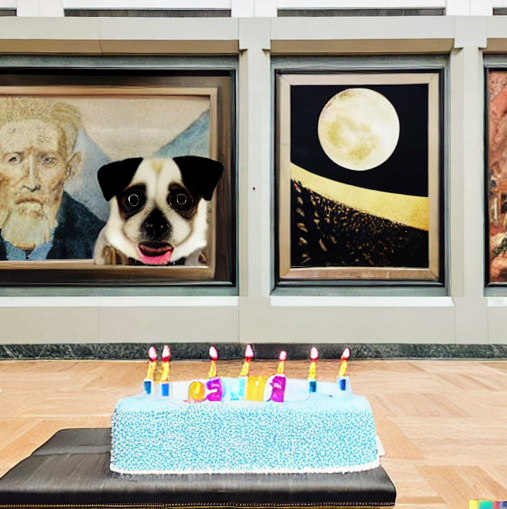

In [4]:
# local_image_path = './imgs/backpack.jpeg'
# local_image_path = './imgs/art_dog_birthdaycake.png'
# local_image_path = './imgs/livingroom_modern.png'
local_image_path = '/home/AIdrawG/static/gener_work/art_dog_birthdaycake.png'

image_source, image = load_image(local_image_path)
Image.fromarray(image_source)

In [5]:
# TEXT_PROMPT = "backpack"
TEXT_PROMPT = "dog"

# import supervision as sv

BOX_TRESHOLD = 0.55
TEXT_TRESHOLD = 0.25


boxes, logits, phrases = predict(
    model=model, 
    image=image, 
    caption=TEXT_PROMPT, 
    box_threshold=BOX_TRESHOLD, 
    text_threshold=TEXT_TRESHOLD
)

annotated_frame = annotate(image_source=image_source, boxes=boxes, logits=logits, phrases=phrases)
annotated_frame = annotated_frame[...,::-1] # BGR to RGB

# image_source: np.ndarray
# annotated_frame: np.ndarray

def generate_masks_with_grounding(image_source, boxes):
    h, w, _ = image_source.shape
    boxes_unnorm = boxes * torch.Tensor([w, h, w, h])
    boxes_xyxy = box_convert(boxes=boxes_unnorm, in_fmt="cxcywh", out_fmt="xyxy").numpy()
    mask = np.zeros_like(image_source)
    for box in boxes_xyxy:
        x0, y0, x1, y1 = box
        mask[int(y0):int(y1), int(x0):int(x1), :] = 255
    return mask

image_mask = generate_masks_with_grounding(image_source, boxes)

SupervisionWarnings: annotate is deprecated: `BoxAnnotator` is deprecated and will be removed in `supervision-0.22.0`. Use `BoundingBoxAnnotator` and `LabelAnnotator` instead


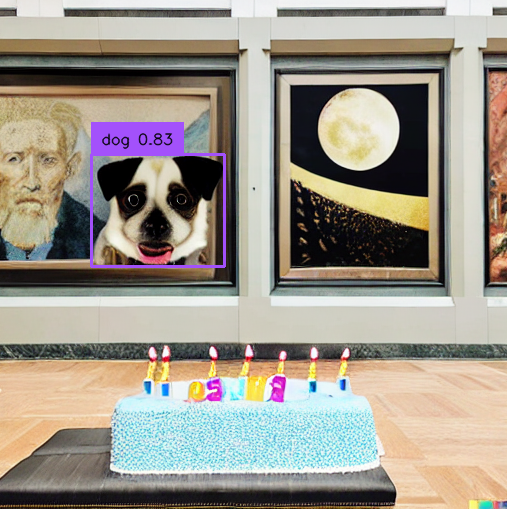

In [6]:
Image.fromarray(annotated_frame)

# Image Inpainting

In [7]:
image_source = Image.fromarray(image_source)
annotated_frame = Image.fromarray(annotated_frame)
image_mask = Image.fromarray(image_mask)

image_source_for_inpaint = image_source.resize((512, 512))
image_mask_for_inpaint = image_mask.resize((512, 512))

num_box = len(boxes)

xyxy_boxes = box_convert(boxes=boxes, in_fmt="cxcywh", out_fmt="xyxy").tolist()
xyxy_boxes

[[0.18099787831306458,
  0.3037703335285187,
  0.44229862093925476,
  0.5241405963897705]]

In [9]:
boxes

tensor([[0.3116, 0.4140, 0.2613, 0.2204]])

In [8]:
prompt = "monkey"
phrases = ["monkey"]

# Insert objects described by text at the region defined by bounding boxes
pipe = StableDiffusionGLIGENPipeline.from_pretrained(
    "masterful/gligen-1-4-inpainting-text-box",
)
pipe = pipe.to("cuda")

images = pipe(
    prompt=prompt,
    gligen_phrases=phrases,
    gligen_inpaint_image=image_source_for_inpaint,
    gligen_boxes=xyxy_boxes,
    gligen_scheduled_sampling_beta=1,
    output_type="pil",
    num_inference_steps=35,
).images

images[0].save("/home/AIdrawG/static/gener_output/test_sd_monkey.jpg")

unet/diffusion_pytorch_model.safetensors not found


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--masterful--gligen-1-4-inpainting-text-box/snapshots/d6d957f8d27c40889c0d570a616571a5645c8be3/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--masterful--gligen-1-4-inpainting-text-box/snapshots/d6d957f8d27c40889c0d570a616571a5645c8be3/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--masterful--gligen-1-4-inpainting-text-box/snapshots/d6d957f8d27c40889c0d570a616571a5645c8be3/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--masterful--gligen-1-4-inpainting-text-box/snapshots/d6d957f8d27c40889c0d570a616571a5645c8be3/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
huggingface/tokenizers: The current process just g

  0%|          | 0/35 [00:00<?, ?it/s]